# Notebook 06 – Adaptive Builder (Merge + Score)

Notebook 05 produced two candidate outputs. This notebook consolidates and scores them; it does **not** generate new rules and does **not** write the final JSON (that is Notebook 07).

| Output | Action |
|--------|--------|
| **Base profiles** (Persona+Mood+Device) | Merge near-duplicate profiles, then score with statistical + ML + rule evidence |
| **Trait modifiers** (Big Five nudges) | Keep one nudge per (Trait, Level, Property), then score with statistical + ML + effect size + coverage |

**Base merge rule:** a more specific profile is merged into a more general one when the general profile subsumes its Persona/Mood/Device context and their UI profiles are ≥ 80% similar.

**Modifier score:** data-driven nudges are ranked above theory-informed fallbacks; every modifier keeps its `Provenance`.

## Expected Outputs
- `reports/AdaptiveProfiles/merged_base_profiles.csv` / `.xlsx`
- `reports/AdaptiveProfiles/scored_trait_modifiers.csv` / `.xlsx`
- `reports/AdaptiveProfiles/figures/` — score distributions, provenance counts

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _bootstrap_project() -> Path:
    search_from = Path.cwd().resolve()
    candidates = [search_from, *search_from.parents]
    nested_root = search_from / "EvidenceBasedAdaptiveUI"
    if (nested_root / "src" / "config.py").exists():
        candidates.insert(0, nested_root)
    for candidate in candidates:
        if (candidate / "src" / "config.py").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise FileNotFoundError("Could not find project root containing src/config.py.")


PROJECT_ROOT = _bootstrap_project()

from src.evidence_engine.adaptive_builder import run_adaptive_builder_pipeline
from src.evidence_engine.modifier_scoring import MODIFIER_SCORE_WEIGHTS
from src.utils.notebook import setup_notebook

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)
plt.rcParams["figure.dpi"] = 300

PATHS, REPORTS = setup_notebook("AdaptiveProfiles")

print("Modifier evidence score weights:")
for component, weight in MODIFIER_SCORE_WEIGHTS.items():
    print(f"  {component.replace('_', ' ')}: {weight:.0%}")

Modifier evidence score weights:
  Statistical Evidence: 30%
  Feature Importance: 25%
  SHAP: 15%
  Effect Size: 15%
  Coverage: 15%


## Check Upstream Inputs

Requires completed runs of Notebooks 03, 04, and 05.

In [2]:
INPUTS = {
    "Base profiles (NB05)": PATHS.reports / "AssociationRules" / "candidate_base_profiles.xlsx",
    "Base rules (NB05)": PATHS.reports / "AssociationRules" / "base_candidate_rules.csv",
    "Trait modifiers (NB05)": PATHS.reports / "AssociationRules" / "trait_modifiers.csv",
    "Statistical results (NB03)": PATHS.reports / "Statistical_Validation" / "tables" / "statistical_results.xlsx",
    "Feature importance (NB04)": PATHS.reports / "Feature_Importance" / "feature_importance.xlsx",
    "SHAP summary (NB04)": PATHS.reports / "Feature_Importance" / "shap_summary.csv",
}

for label, path in INPUTS.items():
    fallback = path.with_suffix(".csv" if path.suffix == ".xlsx" else ".xlsx")
    status = "OK" if path.exists() else ("OK (fallback)" if fallback.exists() else "MISSING")
    print(f"{label}: {status}")

Base profiles (NB05): OK
Base rules (NB05): OK
Trait modifiers (NB05): OK
Statistical results (NB03): OK
Feature importance (NB04): OK
SHAP summary (NB04): OK


## Merge and Score

In [3]:
result = run_adaptive_builder_pipeline(PROJECT_ROOT, REPORTS)

merged_base_profiles = result.merged_base_profiles
scored_trait_modifiers = result.scored_trait_modifiers
summary = result.summary

print(f"Original base profiles: {summary['original_base_profiles']}")
print(f"Merged base profiles:   {summary['merged_base_profiles']} "
      f"(reduction {summary['base_reduction_percent']:.1f}%)")
print(f"Average base profile score: {summary['average_base_profile_score']:.3f}")
print(
    f"Trait modifiers: {summary['trait_modifiers']} "
    f"({summary['modifiers_data_driven']} data-driven, {summary['modifiers_theory']} theory)"
)
print(f"Average modifier evidence score: {summary['average_modifier_score']:.3f}")

INFO: Adaptive builder: 34 base profiles -> 26 merged; 17 trait modifiers scored


Original base profiles: 34
Merged base profiles:   26 (reduction 23.5%)
Average base profile score: 0.534
Trait modifiers: 17 (5 data-driven, 12 theory)
Average modifier evidence score: 0.358


## Merged Base Profiles

Each row is one scored base configuration keyed by Persona / Mood / Device.

In [4]:
base_columns = [
    "Base_Profile_ID",
    "Persona",
    "Mood",
    "Device",
    "Num_UI_Adaptations",
    "Base_Profile_Score",
    "Strength",
    "Participants",
    "Merged_Count",
]
display(merged_base_profiles[base_columns].head(20))

,Base_Profile_ID,Persona,Mood,Device,Num_UI_Adaptations,Base_Profile_Score,Strength,Participants,Merged_Count
0,1,None,Excited,None,1,0.708922,Strong,10,1
1,2,Researcher,Relaxed,Smartphone,1,0.669310,Moderate,10,1
2,3,Researcher,Relaxed,None,2,0.647715,Moderate,10,1
3,4,None,Happy,Smartphone,7,0.615974,Moderate,11,1
4,5,None,Happy,None,9,0.604958,Moderate,13,1
5,6,Deal Hunter,None,None,7,0.604800,Moderate,18,1
6,7,Minimalist,None,Laptop/Desktop,4,0.581158,Moderate,10,1
7,8,Researcher,None,Laptop/Desktop,6,0.579934,Moderate,11,1
8,9,None,Neutral,Laptop/Desktop,8,0.578179,Moderate,11,1
9,10,Minimalist,Neutral,Smartphone,5,0.560954,Moderate,10,1


## Scored Trait Modifiers

One evidence-scored nudge per (Trait, Level, Property). `Provenance` shows whether the nudge came from the survey or from a theory-informed fallback.

In [5]:
modifier_columns = [
    "Trait",
    "Level",
    "Property",
    "Nudge",
    "Direction",
    "Provenance",
    "Cramers_V",
    "Modifier_Evidence_Score",
    "Strength",
]
display(scored_trait_modifiers[modifier_columns])

,Trait,Level,Property,Nudge,Direction,Provenance,Cramers_V,Modifier_Evidence_Score,Strength
0,Agreeableness,High,recommendation_emphasis,1,increase,theory,0.135870,0.326507,Moderate
1,Agreeableness,Low,recommendation_emphasis,1,increase,data-driven,0.135870,0.633345,Strong
2,Conscientiousness,High,information_density,1,increase,theory,0.067581,0.272673,Weak
3,Conscientiousness,Low,information_density,-1,decrease,theory,0.067581,0.258723,Weak
4,Extraversion,High,recommendation_emphasis,-1,decrease,data-driven,0.147525,0.635308,Strong
5,Extraversion,High,information_density,-1,decrease,data-driven,0.092127,0.578200,Strong
6,Extraversion,High,animation_level,1,increase,theory,0.000000,0.013050,Weak
7,Extraversion,Low,recommendation_emphasis,-1,decrease,theory,0.147525,0.323285,Moderate
8,Neuroticism,High,recommendation_emphasis,1,increase,data-driven,0.193360,0.765863,Very Strong
9,Neuroticism,High,information_density,-1,decrease,theory,0.130845,0.361396,Moderate


## Visualizations

base_profile_score_distribution.png


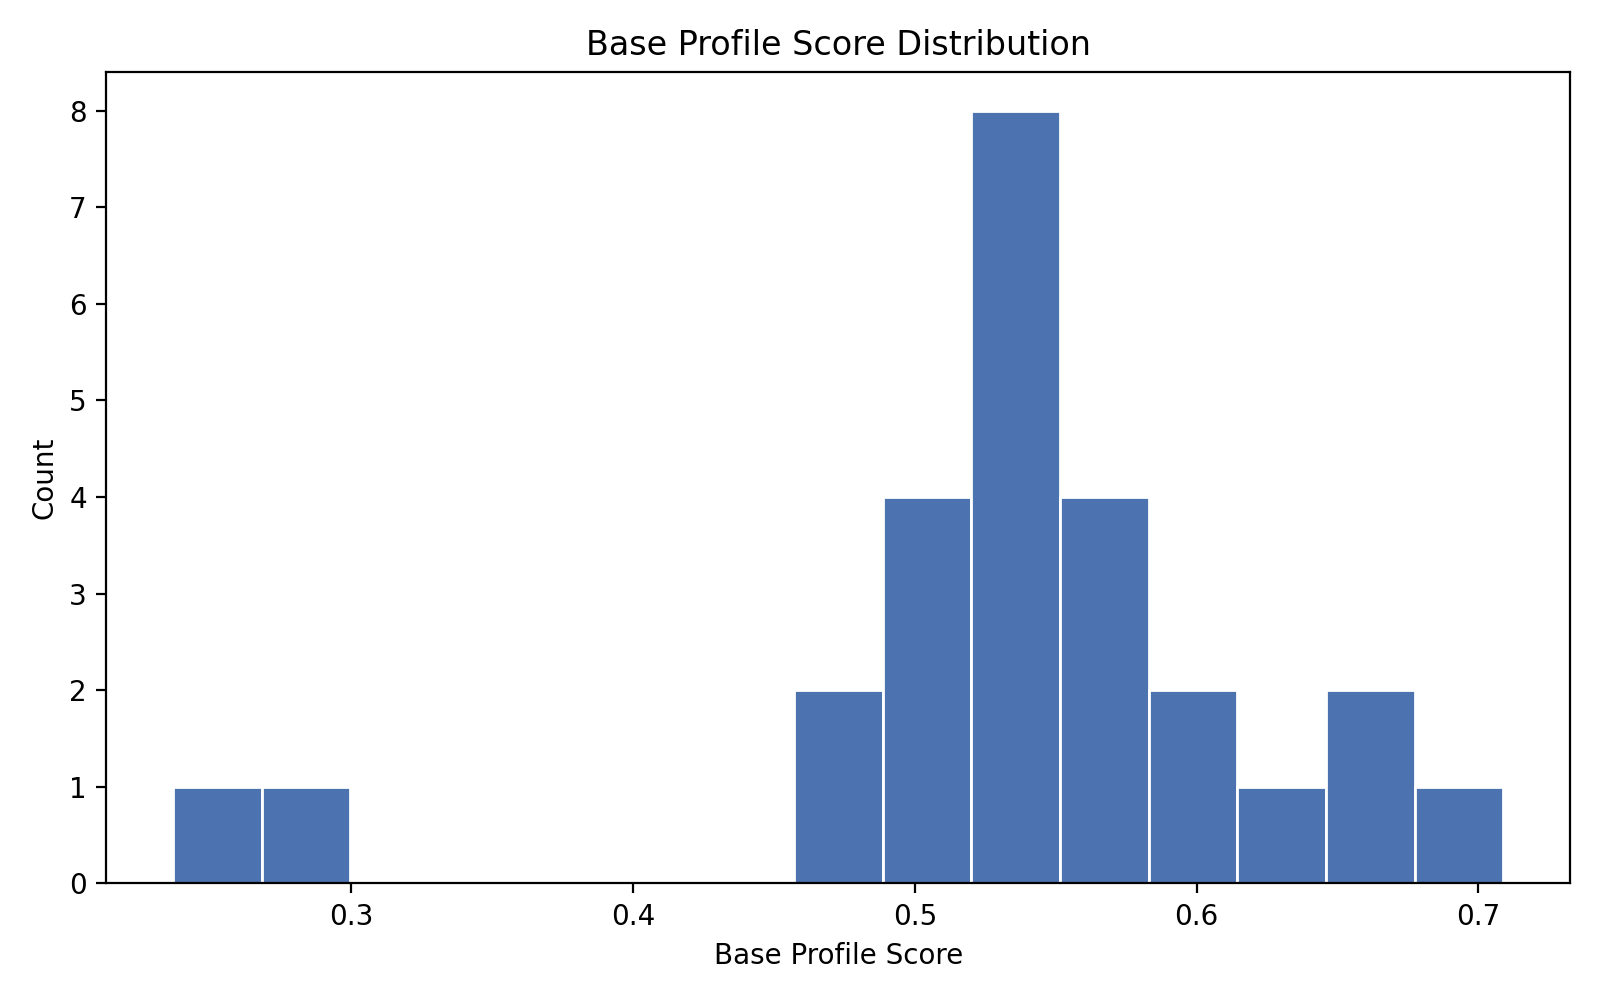

modifier_evidence_distribution.png


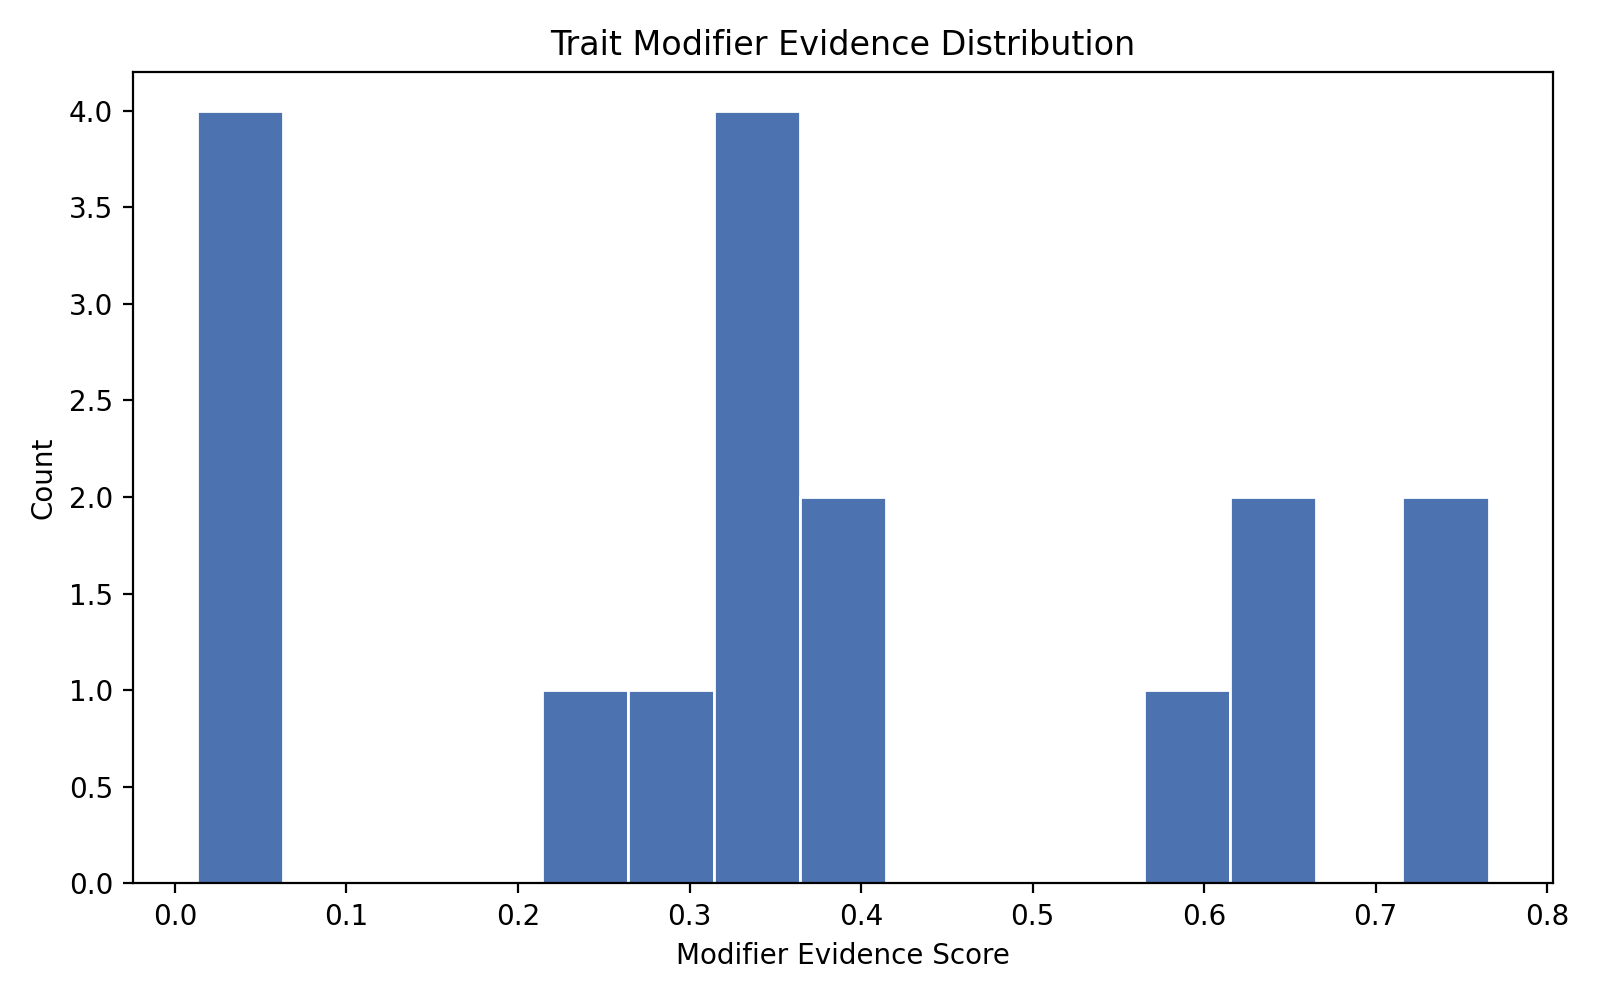

modifier_provenance_counts.png


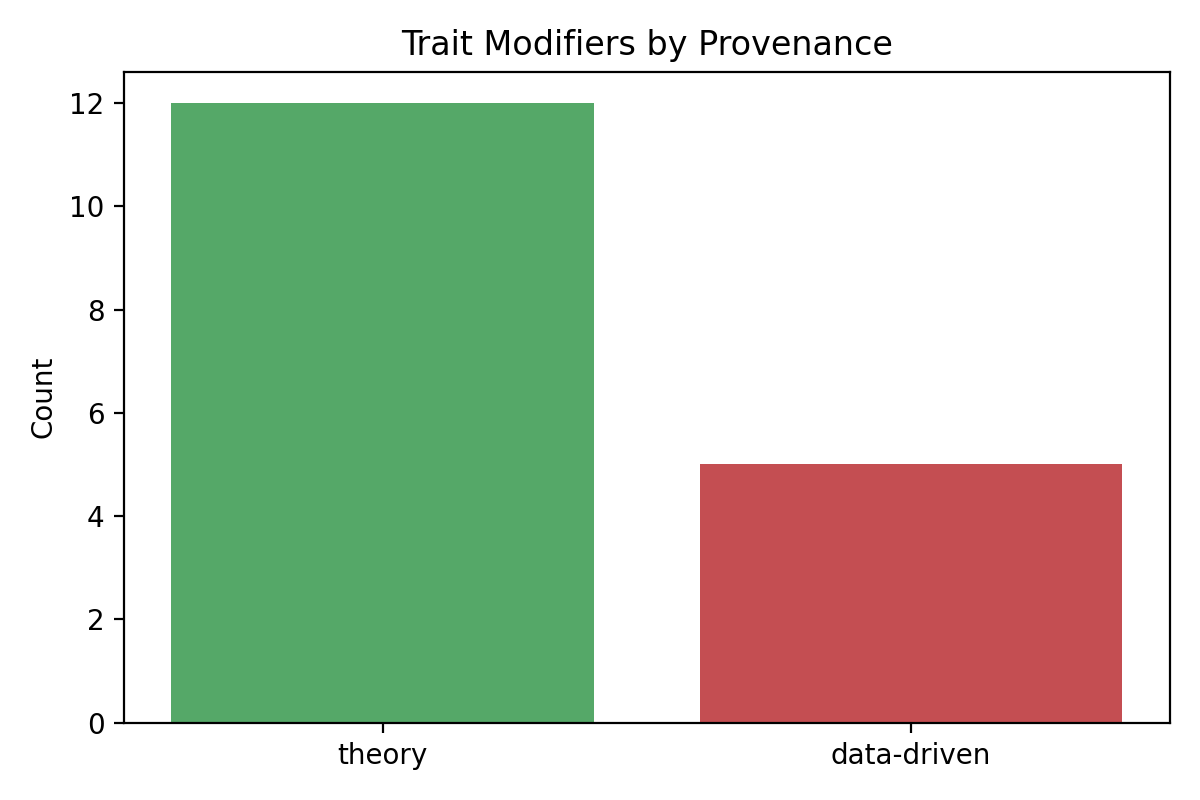

In [6]:
from IPython.display import Image, display as ipy_display

figures_dir = REPORTS / "figures"
for figure_name in [
    "base_profile_score_distribution.png",
    "modifier_evidence_distribution.png",
    "modifier_provenance_counts.png",
]:
    figure_path = figures_dir / figure_name
    if figure_path.exists():
        print(figure_name)
        ipy_display(Image(filename=str(figure_path)))

## Exports

In [7]:
print("Export locations:")
for name, path in result.export_paths.items():
    print(f"- {name}: {path}")

Export locations:
- merged_base_profiles_csv: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/merged_base_profiles.csv
- merged_base_profiles_xlsx: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/merged_base_profiles.xlsx
- scored_trait_modifiers_csv: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/scored_trait_modifiers.csv
- scored_trait_modifiers_xlsx: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/scored_trait_modifiers.xlsx
- base_score_png: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/figures/base_profile_score_distribution.png
- modifier_score_png: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/figures/modifier_evidence_distribution.png
- provenance_png: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveProfiles/figures/modifier_p